In [27]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings

load_dotenv()

db_params = {
    "dbname": "data-sense-db",
    "user": os.getenv("POSTGRES_USERNAME"),
    "password": os.getenv("POSTGRES_PASSWORD"),
    "host": os.getenv("POSTGRES_HOST"),
    "port": "5432",
}

os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN")
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0,
)

llm.invoke("Hello")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10188.51it/s]


AIMessage(content='Hello. How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 36, 'total_tokens': 46, 'completion_time': 0.022176959, 'completion_tokens_details': None, 'prompt_time': 0.001959105, 'prompt_tokens_details': None, 'queue_time': 0.165260058, 'total_time': 0.024136064}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e6e5b-260e-7271-9921-9421ab2031a3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 10, 'total_tokens': 46})

In [28]:
from typing import TypedDict, Optional


class AgentState(TypedDict):
    question: str
    conversation_history: list[dict]

    # Ambiguity Node
    is_ambiguous: bool
    clarifying_question: str

    # RAG - schema context
    schema_context: str

    # SQL Lifecycle
    generated_sql: str
    sql_explanation: str
    is_sql_safe: bool
    safety_error: str
    sql_result: Optional[list[dict]]
    sql_error: Optional[str]
    error_count: int

    # Output
    insight: str
    viz_code: str
    followup_questions: list[str]

    # Final Response
    response: str

## PROMPTs


#### System Prompts


In [55]:
ambiguity = """
You are a query classifier. Your job is to decide if a business question 
can be answered with SQL against the available tables.

Available tables: {tables}
Conversation history: {conversation_history}

RULES:
- If the question mentions any recognizable business concept (revenue, orders, customers, stock, sellers, products, categories, cities) → return CLEAR
- If the question is a follow-up to conversation history → return CLEAR
- Only return AMBIGUOUS if the question is completely unrelated to the tables OR has zero actionable terms (e.g. just "show me something")
- If the question contains any SQL operation words (drop, delete, truncate, alter, update, insert, create) → return CLEAR

Return CLEAR or AMBIGUOUS: <question> — nothing else.
"""

sql_generator = """
You are an expert PostgreSQL Engineer.
Given the schema context below, write ONE optimized SQL Query
that answers the user's question.
Return ONLY the SQL - no markdown fences, no explanation.

IMPORTANT: If conversation history exists, the current question is likely a 
follow-up. Use the history to understand what tables and filters are relevant.

SCHEMA : {schema_context}
CONVERSATION HISTORY (for follow-up context) : {conversation_history}

Rules:
- Never SELECT *
- Always alias aggregations: SUM(x) AS total_x
- Use LIMIT 100 unless user asks for everything
- Never use INSERT / UPDATE / DELETE / TRUNCATE / DROP
- Use date_trunc for time grouping
- For follow-up questions, reuse the same base tables from history
"""

sql_explainer = """
Explain what this SQL query does in 2-3 plain English sentences.
No technical jargon. Write as if explaining to a business user.
"""

sql_rewriter = """
You are a PostgreSQL expert. A SQL query failed with an error.
Your ONLY job is to fix the exact error and return corrected SQL.

STRICT RULES:
- Use ONLY tables and columns that exist in the schema context below
- Do NOT use SELECT * FROM information_schema or any system tables
- Do NOT change the intent of the query — only fix the error
- Return ONLY the corrected SQL, no markdown, no explanation

SCHEMA CONTEXT (these are the ONLY valid tables and columns):
{schema_context}

ORIGINAL QUESTION (use this to understand the intent):
{question}

FAILED SQL:
{failed_sql}

EXACT ERROR:
{db_error}

Think step by step:
1. Read the error — which column or table does not exist?
2. Find the correct column name in the schema context
3. Replace only that part and return the fixed SQL
"""

insight = """
You are a business analyst.
Summarise the query results in 2-3 plain English sentences.
Be specific - mention actual numbers and trends from the data.
If the price or cost part is involved in the insights, the currency should be INR.
"""

viz_code_generator = """
Write a Matplotlib Python snippet to visualise the data. Assume the data is already in a pandas DataFrame called `df`.
RULES: 
- No ```python fences
- No ``` backticks of any kind
- No explanation or comments
- First line must start with 'import' or 'fig'

FIGURE SIZE RULES — calculate dynamically based on data:
- For bar charts: width = max(10, len(df) * 0.8), height = 6
- For horizontal bar charts: width = 10, height = max(6, len(df) * 0.5)
- For line charts: width = max(10, len(df) * 0.4), height = 6
- If number of rows > 15, ALWAYS prefer horizontal bar chart (barh) over vertical bar
- If any label length > 10 characters, ALWAYS use horizontal bar chart (barh)

LABEL RULES:
- For vertical bar: rotate x labels using EXACTLY these two lines:
    ax.tick_params(axis='x', rotation=45)
    plt.setp(ax.get_xticklabels(), ha='right')
- For horizontal bar: no rotation needed, labels are on y axis
- Always use ax.set_xlabel() and ax.set_ylabel()
- Always set a title with ax.set_title(fontsize=14)
- Add value annotations on each bar:
    - Vertical bar: ax.bar_label(ax.containers[0], fmt='%.1f', padding=3)
    - Horizontal bar: ax.bar_label(ax.containers[0], fmt='%.1f', padding=3)

SPACING RULES:
- Always end with plt.tight_layout(pad=2.0)
- Always end with plt.show()
- Never use fig.show()
"""

followup_question = """
Based on the question asked and the insight returned, suggest exactly 3 short follow-up questions the user might want to ask next.
Return as a Python list of strings ONLY. No explanation. No markdown.
Example format: ["Question 1?", "Question 2?", "Question 3?"]
"""

#### Prompt Templates


In [56]:
from langchain_core.prompts import ChatPromptTemplate

AMBIGUITY_PROMPT = ChatPromptTemplate.from_messages(
    [
        ("system", ambiguity),
        ("human", "Question: {question}"),
    ]
)

SQL_PROMPT = ChatPromptTemplate.from_messages(
    [
        ("system", sql_generator),
        ("human", "Question: {question}"),
    ]
)

SQL_EXPLAINER_PROMPT = ChatPromptTemplate.from_messages(
    [
        ("system", sql_explainer),
        ("human", "SQL: {sql}"),
    ]
)

SQL_REWRITER_PROMPT = ChatPromptTemplate.from_messages(
    [
        ("system", sql_rewriter),
        ("human", "Original Question: {question}"),
    ]
)

INSIGHT_WRITER_PROMPT = ChatPromptTemplate.from_messages(
    [
        ("system", insight),
        ("human", "Question: {question}\nResults: {sql_results}"),
    ]
)

VIZ_CODE_PROMPT = ChatPromptTemplate.from_messages(
    [
        ("system", viz_code_generator),
        (
            "human",
            """Question: {question}
Columns: {columns}
Num rows: {num_rows}
Sample data: {sample_data}
Longest label: {longest_label}""",
        ),
    ]
)

FOLLOWUP_PROMPT = ChatPromptTemplate.from_messages(
    [
        ("system", followup_question),
        (
            "human",
            "Question: {question}\nInsight: {insight}\nColumns in result: {columns}",
        ),
    ]
)

### History Helpers


In [31]:
def trim_history(history: list, max_turns: int = 3) -> list:
    return history[-(max_turns * 2) :]


def format_history(history: list) -> str:
    if not history:
        return "No previous conversation."
    return "\n".join(f"{m['role'].upper()}: {m['content']}" for m in history)


def update_history(history: list, question: str, insight: str) -> list:
    history = history + [
        {"role": "user", "content": question},
        {"role": "assistant", "content": insight},
    ]
    return trim_history(history)

### Utils


In [32]:
import psycopg2
from pgvector.psycopg2 import register_vector
from collections import defaultdict

In [33]:
def get_longest_label(df) -> int:
    str_cols = df.select_dtypes(include=["object", "str"]).columns
    if len(str_cols) == 0:
        return 0
    return int(df[str_cols].apply(lambda col: col.astype(str).str.len().max()).max())

In [34]:
def get_all_tables() -> list[str]:
    conn = psycopg2.connect(**db_params)
    cursor = conn.cursor()
    cursor.execute("SELECT DISTINCT table_name FROM schema_chunks ORDER BY table_name")
    tables = [row[0] for row in cursor.fetchall()]
    conn.close()
    return tables

In [35]:
def retrieve_relevant_schema(question: str, top_k: int = 5) -> str:
    vec = embeddings.embed_query(question)
    conn = psycopg2.connect(**db_params)
    register_vector(conn)
    cur = conn.cursor()

    RETRIEVAL_SQL = """
        SELECT
            table_name,
            ROUND(
                MAX(
                    (1 - (embedding <=> %s::vector)) *
                    CASE chunk_type
                        WHEN 'use_cases' THEN 1.4
                        WHEN 'overview'  THEN 1.1
                        ELSE                  1.0
                    END
                )::numeric, 4
            ) AS weighted_similarity
        FROM schema_chunks
        GROUP BY table_name
        ORDER BY MAX(
            (1 - (embedding <=> %s::vector)) *
            CASE chunk_type
                WHEN 'use_cases' THEN 1.4
                WHEN 'overview'  THEN 1.1
                ELSE                  1.0
            END
        ) DESC
        LIMIT %s
    """
    cur.execute(RETRIEVAL_SQL, (vec, vec, top_k))
    top_tables = cur.fetchall()

    print("[RAG] Top tables by weighted similarity:")
    for table, score in top_tables:
        print(f"  {table}: {score}")

    table_names = [row[0] for row in top_tables]
    cur.execute(
        """
        SELECT table_name, chunk_type, ddl_chunk
        FROM schema_chunks
        WHERE table_name = ANY(%s)
        ORDER BY table_name, chunk_type
        """,
        (table_names,),
    )
    chunks = cur.fetchall()
    conn.close()

    table_chunks = defaultdict(list)
    for table, chunk_type, ddl_chunk in chunks:
        table_chunks[table].append(f"-- [{chunk_type}]\n{ddl_chunk}")

    return "\n\n".join(
        f"=== {table} ===\n" + "\n\n".join(table_chunks[table])
        for table in table_names  # preserve relevance order
    )

In [36]:
import pandas as pd


def execute_sql(query: str):
    try:
        conn = psycopg2.connect(**db_params)
        cur = conn.cursor()
        cur.execute(query)
        cols = [d[0] for d in cur.description]
        rows = [dict(zip(cols, row)) for row in cur.fetchall()]
        conn.close()
        return rows, None
    except Exception as e:
        return None, str(e)

### Nodes


#### Ambiguity Detector


In [37]:
def ambiguity_detector(state: AgentState) -> AgentState:
    tables = get_all_tables()
    print(tables)
    result = (
        (AMBIGUITY_PROMPT | llm)
        .invoke(
            {
                "question": state["question"],
                "tables": ", ".join(tables),
                "conversation_history": format_history(
                    state.get("conversation_history", [])
                ),
            }
        )
        .content.strip()
    )

    if result.upper().startswith("AMBIGUOUS"):
        clarifying = (
            result.split(":", 1)[-1].strip()
            if ":" in result
            else "Could you clarify your question?"
        )
        print(f"[Ambiguity] Clarification needed: {clarifying}")
        return {**state, "is_ambiguous": True, "clarifying_question": clarifying}

    print("[Ambiguity] CLEAR")
    return {**state, "is_ambiguous": False, "clarifying_question": ""}

#### Retrieve Schema


In [38]:
def retrieve_schema(state: AgentState) -> AgentState:
    context = retrieve_relevant_schema(state["question"])
    print(f"[RAG] Retrieved {len(context)} chars")
    return {**state, "schema_context": context}

#### Generate SQL


In [39]:
def generate_sql(state: AgentState) -> AgentState:
    sql_chain = SQL_PROMPT | llm
    sql = sql_chain.invoke(
        {
            "question": state["question"],
            "schema_context": state["schema_context"],
            "conversation_history": format_history(
                state.get("conversation_history", [])
            ),
        }
    ).content.strip()
    print(f"[SQL]\n{sql}")
    return {**state, "generated_sql": sql}

#### Validate SQL


In [40]:
import re


def validate_sql(state: AgentState) -> AgentState:
    BLOCKED_KEYWORDS = [
        "insert",
        "update",
        "delete",
        "drop",
        "truncate",
        "alter",
        "create",
    ]
    lower = state["generated_sql"].lower()
    for keyword in BLOCKED_KEYWORDS:
        if re.search(rf"\b{keyword}\b", lower):
            print(f"[Validator] BLOCKED — found keyword: {keyword}")
            return {
                **state,
                "is_sql_safe": False,
                "safety_error": f"Blocked keyword: {keyword}",
            }
    print("[Validator] SQL is safe.")
    return {**state, "is_sql_safe": True, "safety_error": ""}

#### Execute SQL


In [41]:
def execute_sql_node(state: AgentState) -> AgentState:
    rows, error = execute_sql(state["generated_sql"])
    if error:
        print(f"[Execute] Error: {error}")
        return {
            **state,
            "sql_result": None,
            "sql_error": error,
            "error_count": state.get("error_count", 0) + 1,
        }
    if not rows:
        print("[Execute] Query returned 0 rows.")
        return {**state, "sql_result": [], "sql_error": None}
    print(f"[Execute] {len(rows)} rows returned.")
    return {**state, "sql_result": rows, "sql_error": None}

#### Rewrite SQL


In [42]:
def rewrite_sql(state: AgentState) -> AgentState:
    print(f"[Rewrite] Attempt {state['error_count']}...")
    rewriter_chain = SQL_REWRITER_PROMPT | llm
    sql = rewriter_chain.invoke(
        {
            "schema_context": state["schema_context"],
            "failed_sql": state["generated_sql"],
            "db_error": state["sql_error"],
            "question": state["question"],
        }
    ).content.strip()
    print(f"[Rewrite] New SQL:\n{sql}")
    return {**state, "generated_sql": sql, "sql_error": None}

#### Explain SQL


In [43]:
def explain_sql(state: AgentState) -> AgentState:
    if not state.get("generated_sql"):
        return {**state, "sql_explanation": "No SQL was generated."}
    explanation = (
        (SQL_EXPLAINER_PROMPT | llm)
        .invoke({"sql": state["generated_sql"]})
        .content.strip()
    )
    print(f"[Explain] {explanation}")
    return {**state, "sql_explanation": explanation}

#### Generate Insights


In [44]:
def generate_insight(state: AgentState) -> AgentState:
    if not state.get("sql_result"):
        return {**state, "insight": "No results to analyse."}
    insight_text = (
        (INSIGHT_WRITER_PROMPT | llm)
        .invoke(
            {
                "question": state["question"],
                "sql_results": str(state["sql_result"][:20]),
            }
        )
        .content.strip()
    )
    print(f"[Insight] {insight_text}")
    return {**state, "insight": insight_text}

#### Generate Viz


In [45]:
def generate_viz(state: AgentState) -> AgentState:
    if not state.get("sql_result"):
        return {**state, "viz_code": ""}
    df = pd.DataFrame(state["sql_result"])
    if df.empty:
        return {**state, "viz_code": ""}
    viz_code = (
        (VIZ_CODE_PROMPT | llm)
        .invoke(
            {
                "question": state["question"],
                "columns": list(df.columns),
                "num_rows": len(df),
                "sample_data": df.head(3).to_dict(orient="records"),
                "longest_label": get_longest_label(df),
            }
        )
        .content
    )
    print(f"[Viz]\n{viz_code}")
    return {**state, "viz_code": viz_code}

#### Followup Questions


In [46]:
def suggest_followups(state: AgentState) -> AgentState:
    if not state.get("sql_result"):
        return {**state, "followup_questions": []}
    df = pd.DataFrame(state["sql_result"])
    raw = (
        (FOLLOWUP_PROMPT | llm)
        .invoke(
            {
                "question": state["question"],
                "insight": state["insight"],
                "columns": list(df.columns),
            }
        )
        .content.strip()
    )
    try:
        followups = eval(raw)
    except Exception:
        followups = [raw]
    print(f"[Follow-ups] {followups}")
    return {**state, "followup_questions": followups}

### Conditional Edges


In [47]:
from langgraph.graph import StateGraph, END

MAX_RETRIES = 3


def route_ambiguity(state: AgentState) -> str:
    return "end_ambiguous" if state["is_ambiguous"] else "retrieve_schema"


def route_validation(state: AgentState) -> str:
    return "end_blocked" if not state["is_sql_safe"] else "execute_sql"


def route_execution(state: AgentState) -> str:
    if state.get("sql_error"):
        if state.get("error_count", 0) < MAX_RETRIES:
            return "rewrite_sql"
        return "end_error"
    return "explain_sql"

In [48]:
def build_graph():
    graph = StateGraph(AgentState)
    graph.add_node("ambiguity_detector", ambiguity_detector)
    graph.add_node("retrieve_schema", retrieve_schema)
    graph.add_node("generate_sql", generate_sql)
    graph.add_node("validate_sql", validate_sql)
    graph.add_node("execute_sql", execute_sql_node)
    graph.add_node("rewrite_sql", rewrite_sql)
    graph.add_node("explain_sql", explain_sql)
    graph.add_node("generate_insight", generate_insight)
    graph.add_node("generate_viz", generate_viz)
    graph.add_node("suggest_followups", suggest_followups)

    graph.set_entry_point("ambiguity_detector")

    graph.add_conditional_edges(
        "ambiguity_detector",
        route_ambiguity,
        {"end_ambiguous": END, "retrieve_schema": "retrieve_schema"},
    )

    graph.add_edge("retrieve_schema", "generate_sql")
    graph.add_edge("generate_sql", "validate_sql")

    graph.add_conditional_edges(
        "validate_sql",
        route_validation,
        {"end_blocked": END, "execute_sql": "execute_sql"},
    )

    graph.add_conditional_edges(
        "execute_sql",
        route_execution,
        {"rewrite_sql": "rewrite_sql", "end_error": END, "explain_sql": "explain_sql"},
    )

    graph.add_edge("rewrite_sql", "execute_sql")
    graph.add_edge("explain_sql", "generate_insight")
    graph.add_edge("generate_insight", "generate_viz")
    graph.add_edge("generate_viz", "suggest_followups")
    graph.add_edge("suggest_followups", END)

    return graph.compile()


agent = build_graph()

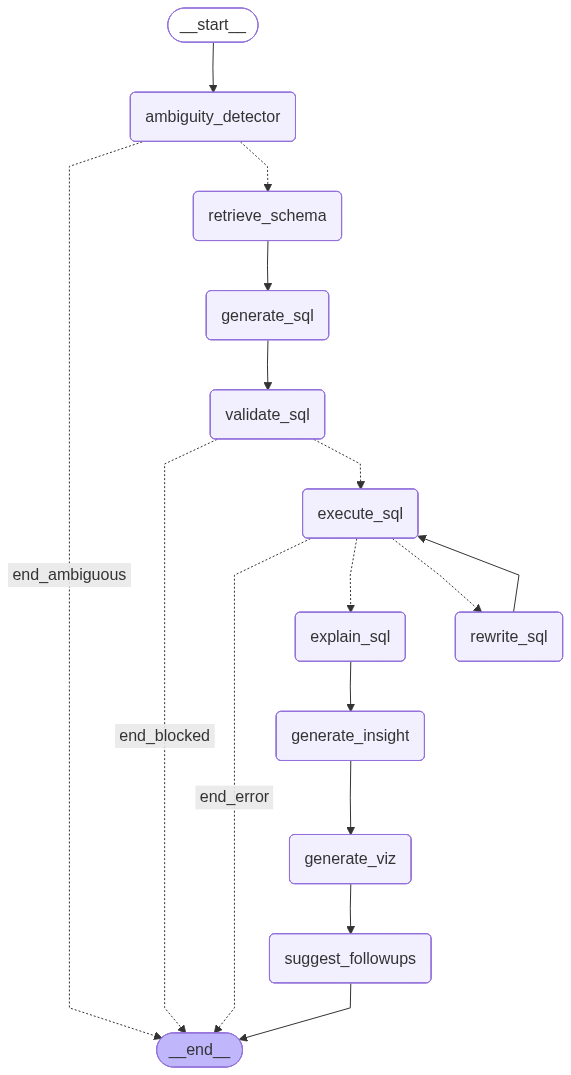

In [49]:
from IPython.display import display, Image

display(Image(agent.get_graph().draw_mermaid_png()))

In [50]:
def run_agent(question: str, conversation_history: list = []):
    print(f"\n{'=' * 60}")
    print(f"Question: {question}")
    print(f"{'=' * 60}")

    if conversation_history:
        print(f"[History] {len(conversation_history)} messages in context")
        for m in conversation_history:
            print(f"  {m['role'].upper()}: {m['content'][:80]}")

    result = agent.invoke(
        {
            "question": question,
            "conversation_history": conversation_history,
            "error_count": 0,
            "is_ambiguous": False,
            "is_sql_safe": True,
        }
    )

    if result.get("is_ambiguous"):
        print(f"\n[Clarification Needed]\n{result['clarifying_question']}")
        return result, conversation_history

    if not result.get("is_sql_safe"):
        print(f"\n[Blocked]\n{result['safety_error']}")
        return result, conversation_history

    if not result.get("sql_result"):
        print("\n[No Results] Query returned no data.")
        return result, conversation_history

    df = pd.DataFrame(result["sql_result"])
    print(f"\n[SQL]\n{result['generated_sql']}")
    print(f"\n[Explanation]\n{result['sql_explanation']}")
    print(f"\n[Result] {len(df)} rows\n{df.head()}")
    print(f"\n[Insight]\n{result['insight']}")
    print("\n[Follow-up Suggestions]")
    for i, q in enumerate(result.get("followup_questions", []), 1):
        print(f"  {i}. {q}")

    # FIX: guard exec — only run if viz_code is non-empty
    if result.get("viz_code"):
        exec(result["viz_code"])

    updated_history = update_history(conversation_history, question, result["insight"])
    return result, updated_history


Question: What is the total revenue generated by each seller?
['customers', 'inventory', 'order_items', 'order_payments', 'orders', 'products', 'sellers']
[Ambiguity] CLEAR
[RAG] Top tables by weighted similarity:
  order_items: 0.5618
  sellers: 0.5121
  products: 0.4491
  orders: 0.3400
  customers: 0.3273
[RAG] Retrieved 13279 chars
[SQL]
SELECT 
  oi.seller_id, 
  SUM(oi.subtotal) AS total_revenue
FROM 
  order_items oi
GROUP BY 
  oi.seller_id
ORDER BY 
  total_revenue DESC
LIMIT 100;
[Validator] SQL is safe.
[Execute] 100 rows returned.
[Explain] This query calculates the total revenue for each seller and lists the top 100 sellers with the highest total revenue. It adds up the subtotal of all orders for each seller and then ranks them from highest to lowest. The result is a list of the top-performing sellers based on their total sales.
[Insight] The top seller, SELL00952, generated a total revenue of approximately INR 26.53 lakh, followed by SELL00275 with INR 26.18 lakh. The to

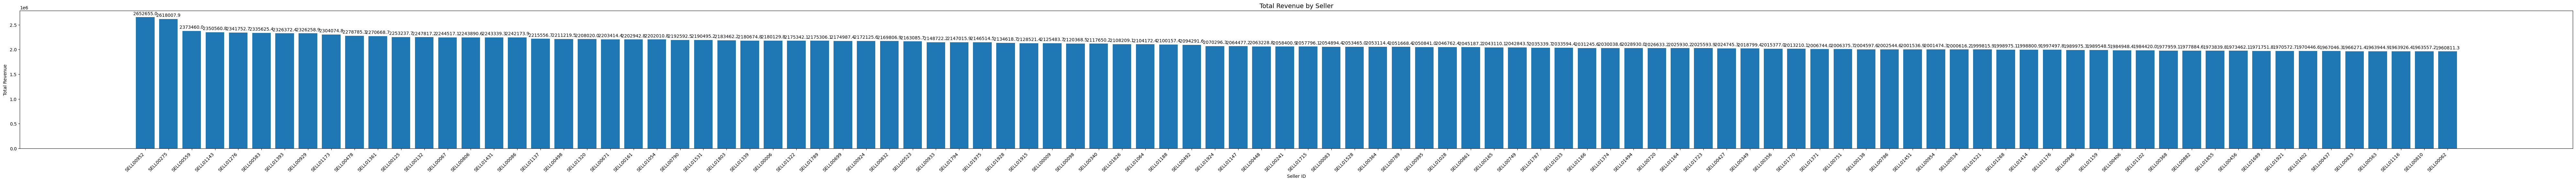

In [51]:
# Single turn
result, history = run_agent("What is the total revenue generated by each seller?")


Question: Which of those sellers are based in Mumbai?
[History] 2 messages in context
  USER: What is the total revenue generated by each seller?
  ASSISTANT: The top seller, SELL00952, generated a total revenue of approximately INR 26.53 
['customers', 'inventory', 'order_items', 'order_payments', 'orders', 'products', 'sellers']
[Ambiguity] CLEAR
[RAG] Top tables by weighted similarity:
  sellers: 0.5741
  customers: 0.4986
  orders: 0.4577
  inventory: 0.4385
  products: 0.4005
[RAG] Retrieved 13014 chars
[SQL]
SELECT seller_id, seller_name, seller_type, rating, total_products 
FROM sellers 
WHERE city = 'Mumbai' 
LIMIT 100;
[Validator] SQL is safe.
[Execute] 44 rows returned.
[Explain] This query retrieves a list of sellers who are based in Mumbai, including their name, type, rating, and the total number of products they offer. The list is limited to the first 100 sellers that match this criteria. It helps to get a snapshot of sellers operating in Mumbai.
[Insight] There are 2 sel

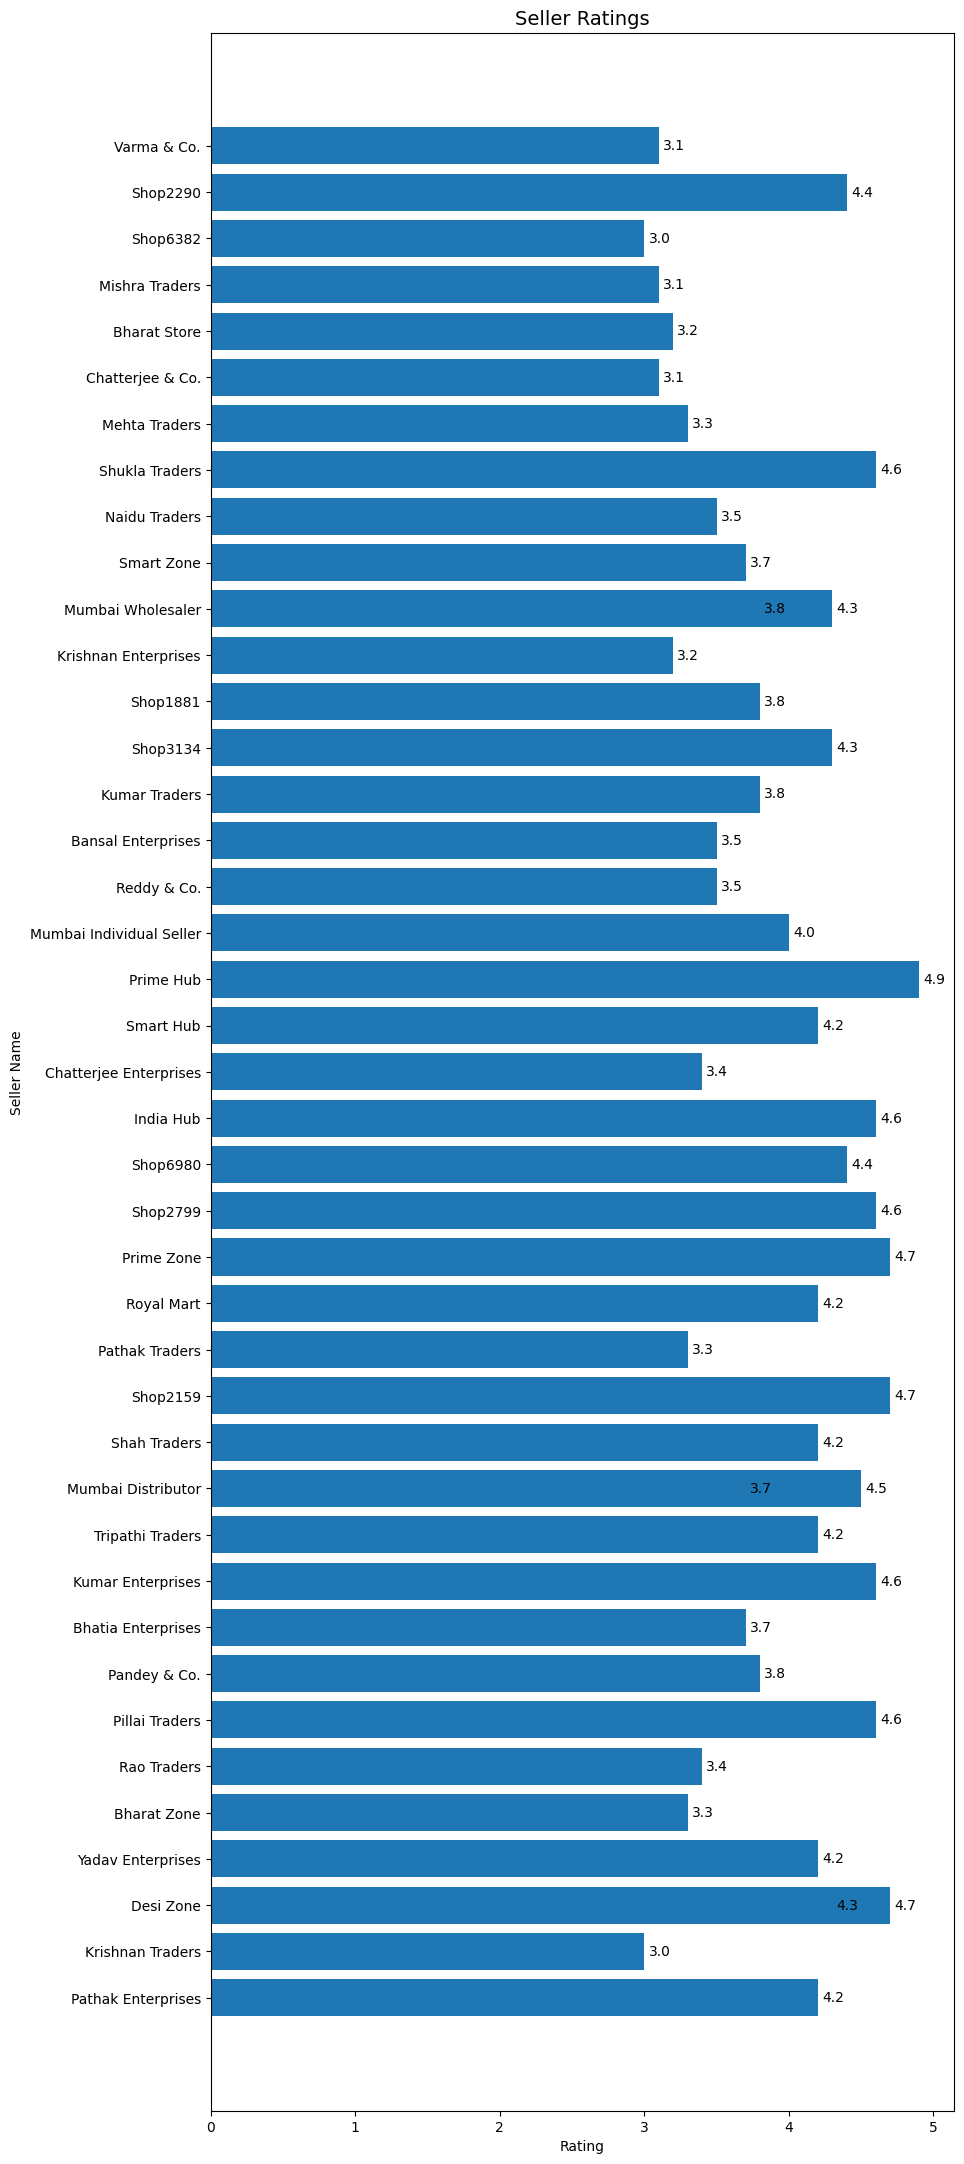

In [52]:
result, history = run_agent(
    "Which of those sellers are based in Mumbai?", conversation_history=history
)

In [53]:
result, _ = run_agent("show me data")  # should trigger ambiguity


Question: show me data
['customers', 'inventory', 'order_items', 'order_payments', 'orders', 'products', 'sellers']
[Ambiguity] Clarification needed: Could you clarify your question?

[Clarification Needed]
Could you clarify your question?


In [57]:
result, _ = run_agent("drop the orders table")  # should trigger validator


Question: drop the orders table
['customers', 'inventory', 'order_items', 'order_payments', 'orders', 'products', 'sellers']
[Ambiguity] CLEAR
[RAG] Top tables by weighted similarity:
  inventory: 0.6350
  orders: 0.5917
  order_items: 0.5869
  order_payments: 0.5142
  customers: 0.4646
[RAG] Retrieved 12249 chars
[SQL]
DROP TABLE orders;
[Validator] BLOCKED — found keyword: drop

[Blocked]
Blocked keyword: drop
